# Chromatin PTR analysis
March 18, 2024

Simple PTR analysis to compare deconvolved PTR to raw PTR.

Then compare deconvolved PTR to gene expression deconvovled PTR.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
import glob

outdir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'

from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

peak_to_trough_analysis = PeakToTroughAnalysis(outdir)


In [4]:
from src.timer import Timer

timer = Timer()

peak_to_trough_analysis.load_ptr_files()
peak_to_trough_analysis.sort_gene_ptrs()
peak_to_trough_analysis.compute_gene_ptr_rank_per_k()

timer.get_time()


'00:00:03.47'

## Evaluating different metrics to summarize gene PTR's

Next, we will evaluate other metrics that can capture a larger summary of the PTR image per gene. 

Metrics:
- Mean
- Median
- Quantiles: 80, 20

Evaluation:
- Plot a set of 20 genes and their PTR images, and evaluate how each metric measures up per gene.


In [5]:
mean = peak_to_trough_analysis.summarize_ptrs(np.mean)
median = peak_to_trough_analysis.summarize_ptrs(np.median)
q95 = peak_to_trough_analysis.compute_q_vals(0.95)
q90 = peak_to_trough_analysis.compute_q_vals(0.9)

means_df = peak_to_trough_analysis.geneset[['gene']].loc[mean.index.values]
means_df['mean_ptr'] = mean.loc[means_df.index.values].values
means_df = means_df.sort_values('mean_ptr', ascending=False)

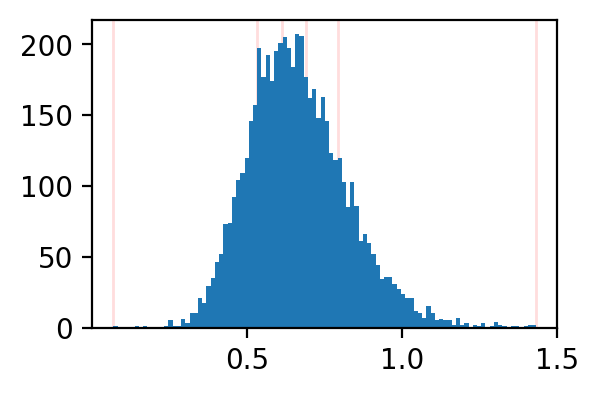

In [6]:
from src.ptr_analysis_plotter import PTRAnalysisPlotter

plotter = PTRAnalysisPlotter(peak_to_trough_analysis, mean)
plotter.set_quantiles(np.linspace(1.0, .0, 6))
plotter.plot_distribution()

140


Text(0.5, 1.0, 'Mean PTR per Gene')

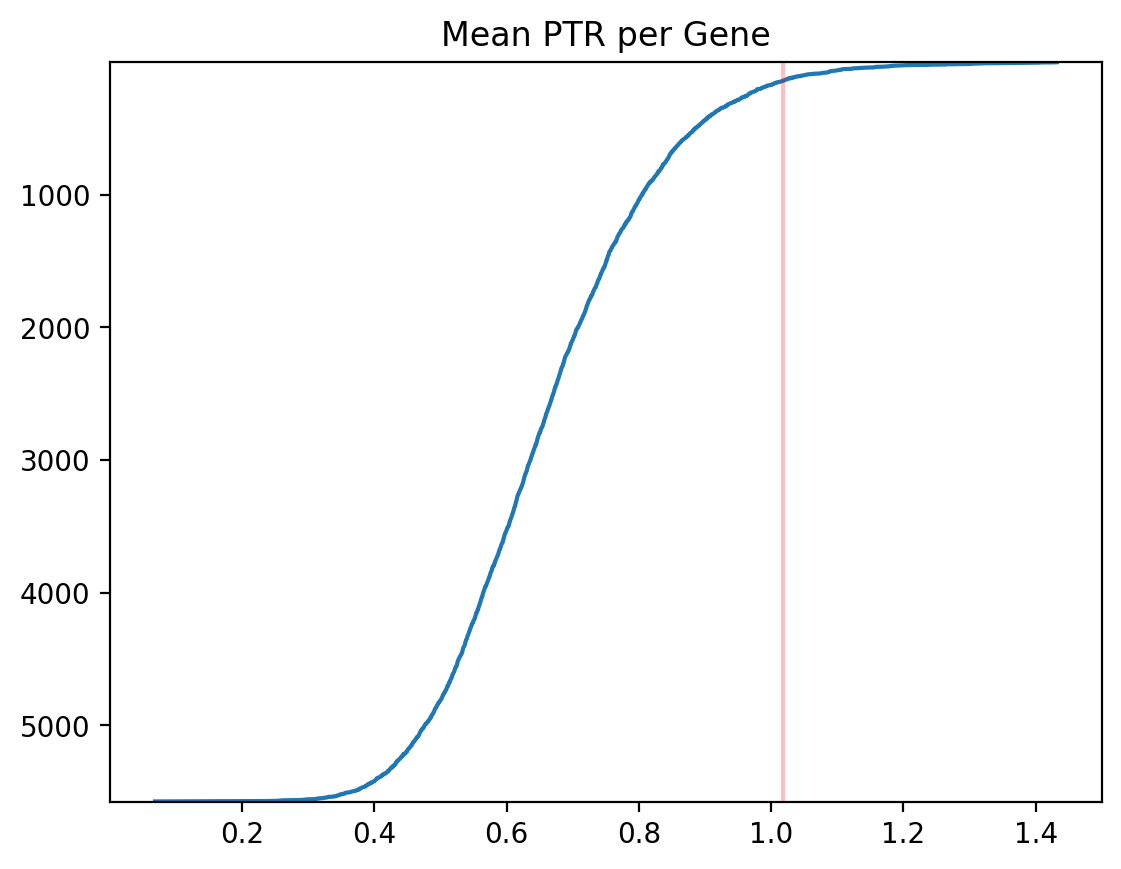

In [7]:
n = len(q95)
xs = np.arange(n)
ys = mean.sort_values(ascending=False)
plt.plot(ys, xs)
plt.ylim(n, 1)

q95_val = np.quantile(mean, 0.975)
print(len(mean[mean > q95_val]))
plt.axvline(q95_val, c='red', alpha=0.25)
plt.title("Mean PTR per Gene")

['CSI2', 'MBF1', 'SPT3', 'YMD8', 'SIZ1', 'CUP1-2']

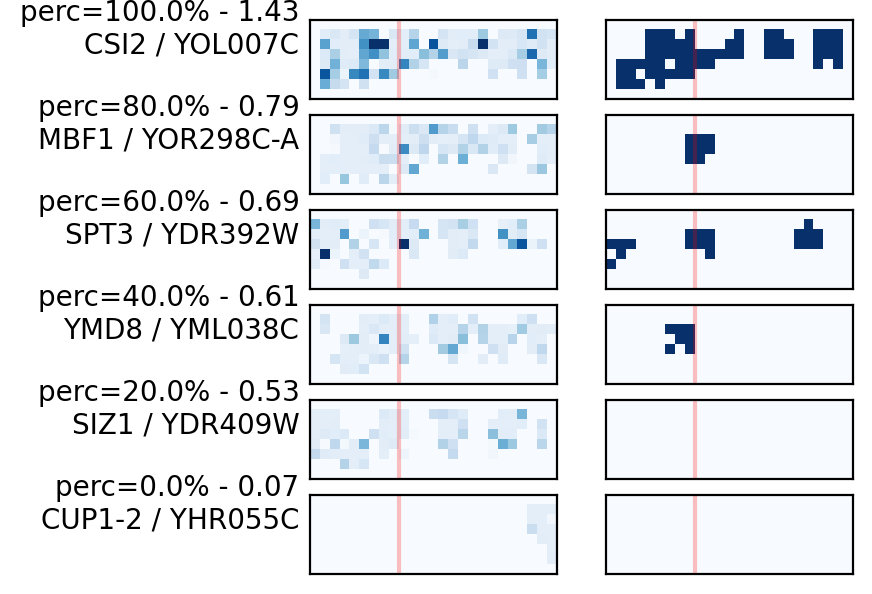

In [8]:
plotter.set_quantiles(np.linspace(1.0, .0, 6))
plotter.plot_metric_examples_quantiles(low=1, hi=6)

['CSI2', 'DIP5', 'PTP3', 'TMT1', 'GTO1', 'KTR1']

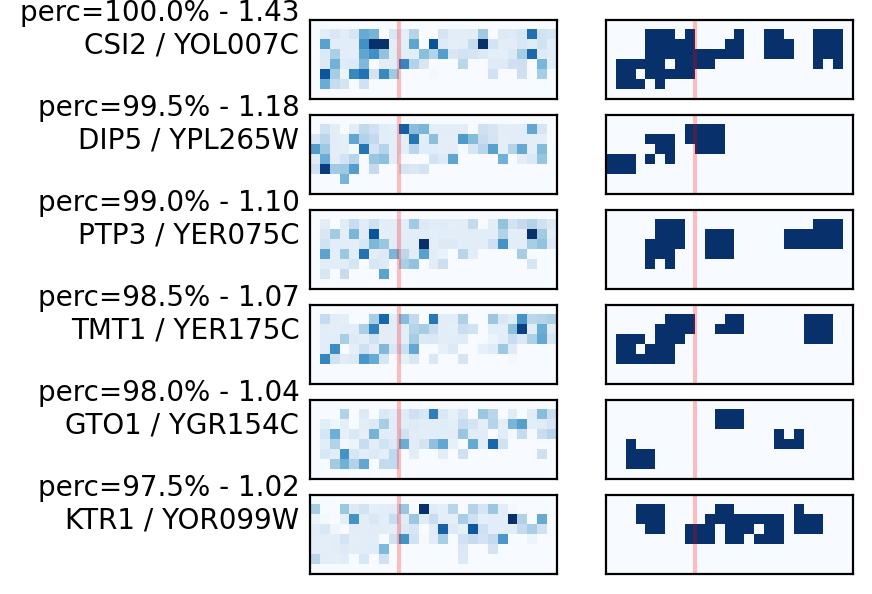

In [9]:
plotter.set_quantiles(np.linspace(1.0, 0.975, 6))
plotter.plot_metric_examples_quantiles(low=1, hi=6)

In [44]:
def load_join_yulong_fourier_score(csv_path, means_df):
    # Load the Yulong Fourier scores for each gene
    promoter_tf_scores = pd.read_csv(csv_path)
    promoter_tf_scores = promoter_tf_scores.set_index('Gene_ID')
    prom_tf_fourier_vs_ptr_comparison = promoter_tf_scores.join(means_df)
    return prom_tf_fourier_vs_ptr_comparison

prom_tf_path = 'data/reference_data/yulongs_2023_Table_S1_promoter_tf_score.csv'
tf_joined_df = load_join_yulong_fourier_score(prom_tf_path, 
                                              means_df)
gb_nuc_path = 'data/reference_data/yulongs_2023_Table_S1_gene_body_nuc_score.csv'
nuc_joined_df = load_join_yulong_fourier_score(gb_nuc_path,
                                               means_df)


Text(0.5, 1.0, 'Nucleosome fourier score vs TF fourier score')

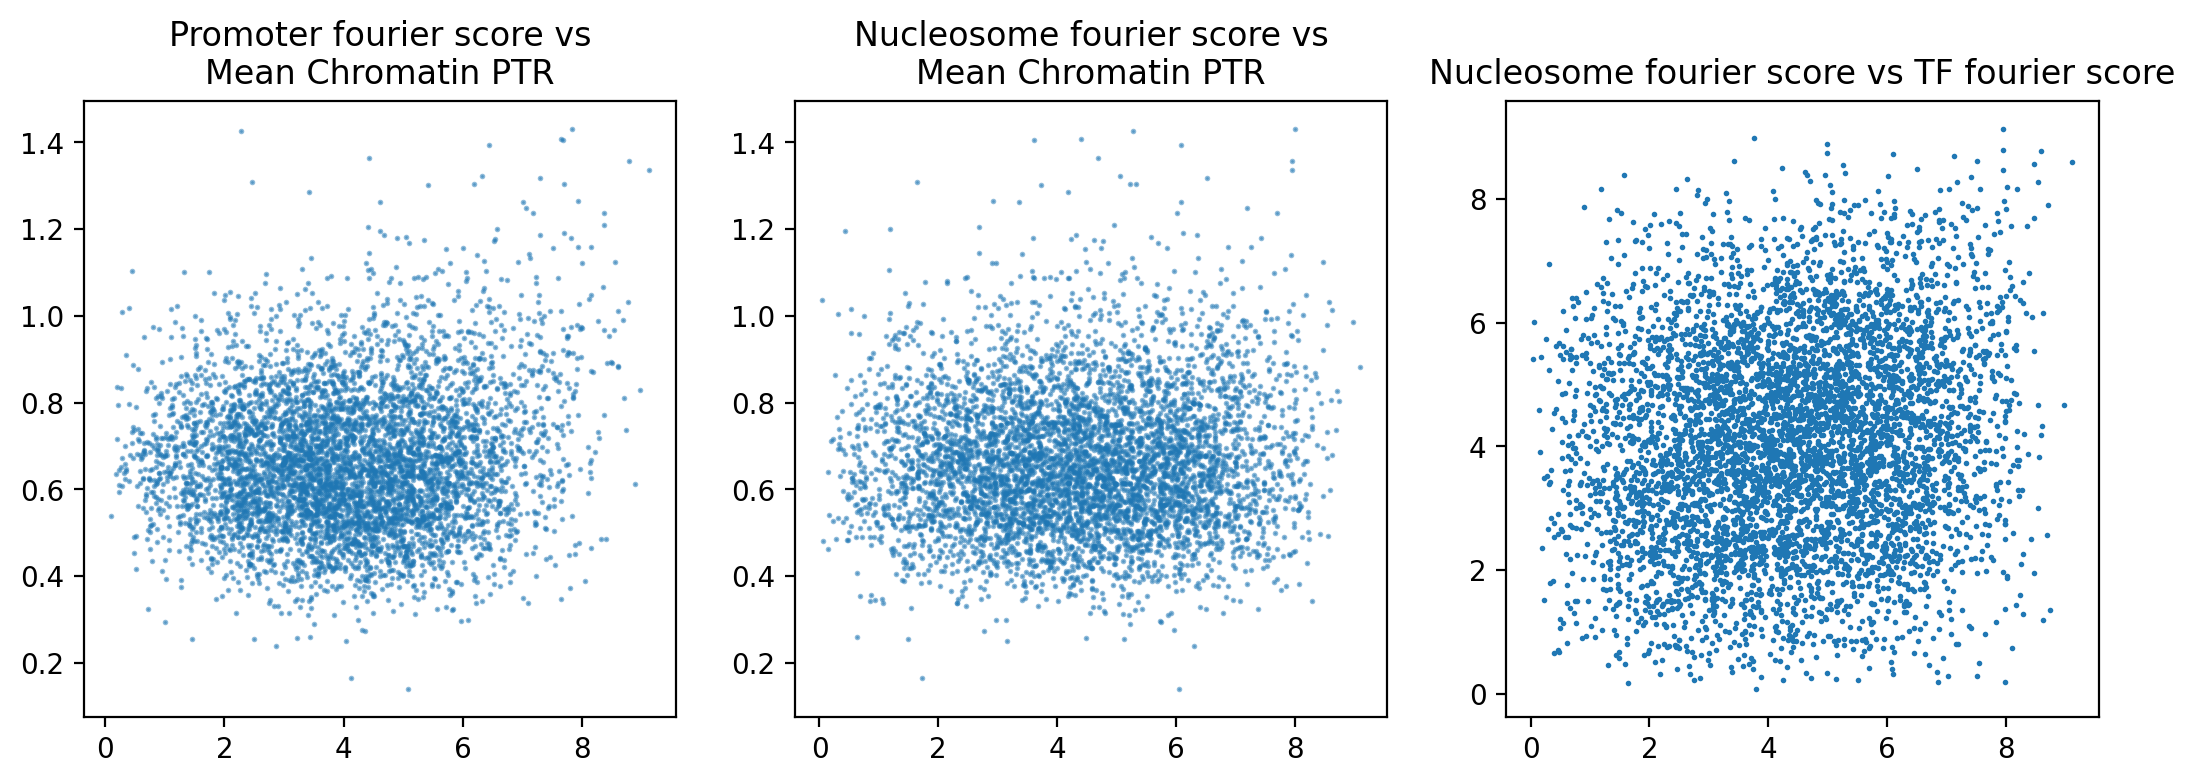

In [42]:
plt.figure(figsize=(13, 4))
plt.subplot(1, 3, 1)
plt.scatter(tf_joined_df['Fourier_score'], 
            tf_joined_df['mean_ptr'], s=1, alpha=0.5)
plt.title("Promoter fourier score vs\nMean Chromatin PTR")

plt.subplot(1, 3, 2)
plt.scatter(nuc_joined_df['Fourier_score'], 
            nuc_joined_df['mean_ptr'], s=1, alpha=0.5)
plt.title("Nucleosome fourier score vs\nMean Chromatin PTR")

plt.subplot(1, 3, 3)
plt_data = tf_joined_df.join(nuc_joined_df, lsuffix='_tf', rsuffix='_nuc')
plt.scatter(plt_data.Fourier_score_nuc, plt_data.Fourier_score_tf, s=1)
plt.title("Nucleosome fourier score vs TF fourier score")


In [43]:
# The deconvolved PTR scores don't appear correlated at all to the Fourier scores,
# 
# Correlate each to gene expression, the argument should be that the deconvolved chromatin
# PTR should be more correlated to gene expression that the Fourier score
#
# What is ground truth? That cycling chromatin should be associated with 
# cycling gene expression
#
# Compare the cycling chromatin to the raw data PTR scores
# ---- The deconvolved PTR scores should be clearly higher
#